<a href="https://colab.research.google.com/github/AyushiTewari406/PyTorch_Fundamentals/blob/main/PyTorch_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

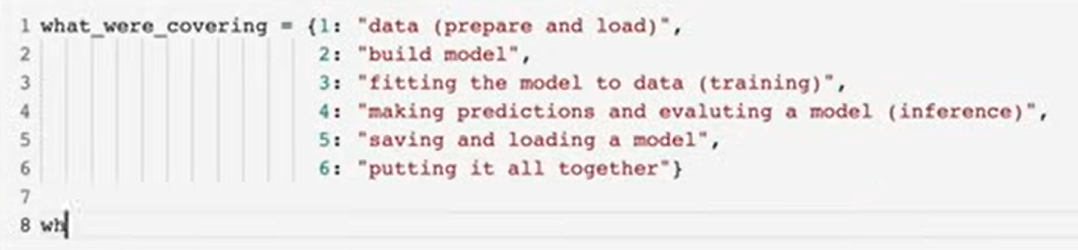

Python Workflow

nn contains pytorch neural networks

In [50]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__


'2.11.0+cpu'

data prep and loading

data can be anything
1. excel
2.images
3.videos
4.audio like songs or podcasts
5.DNA
6.text


ML in 2 parts
1. get data into numerical representation

2. build a model to learn patterns in that numerical representation

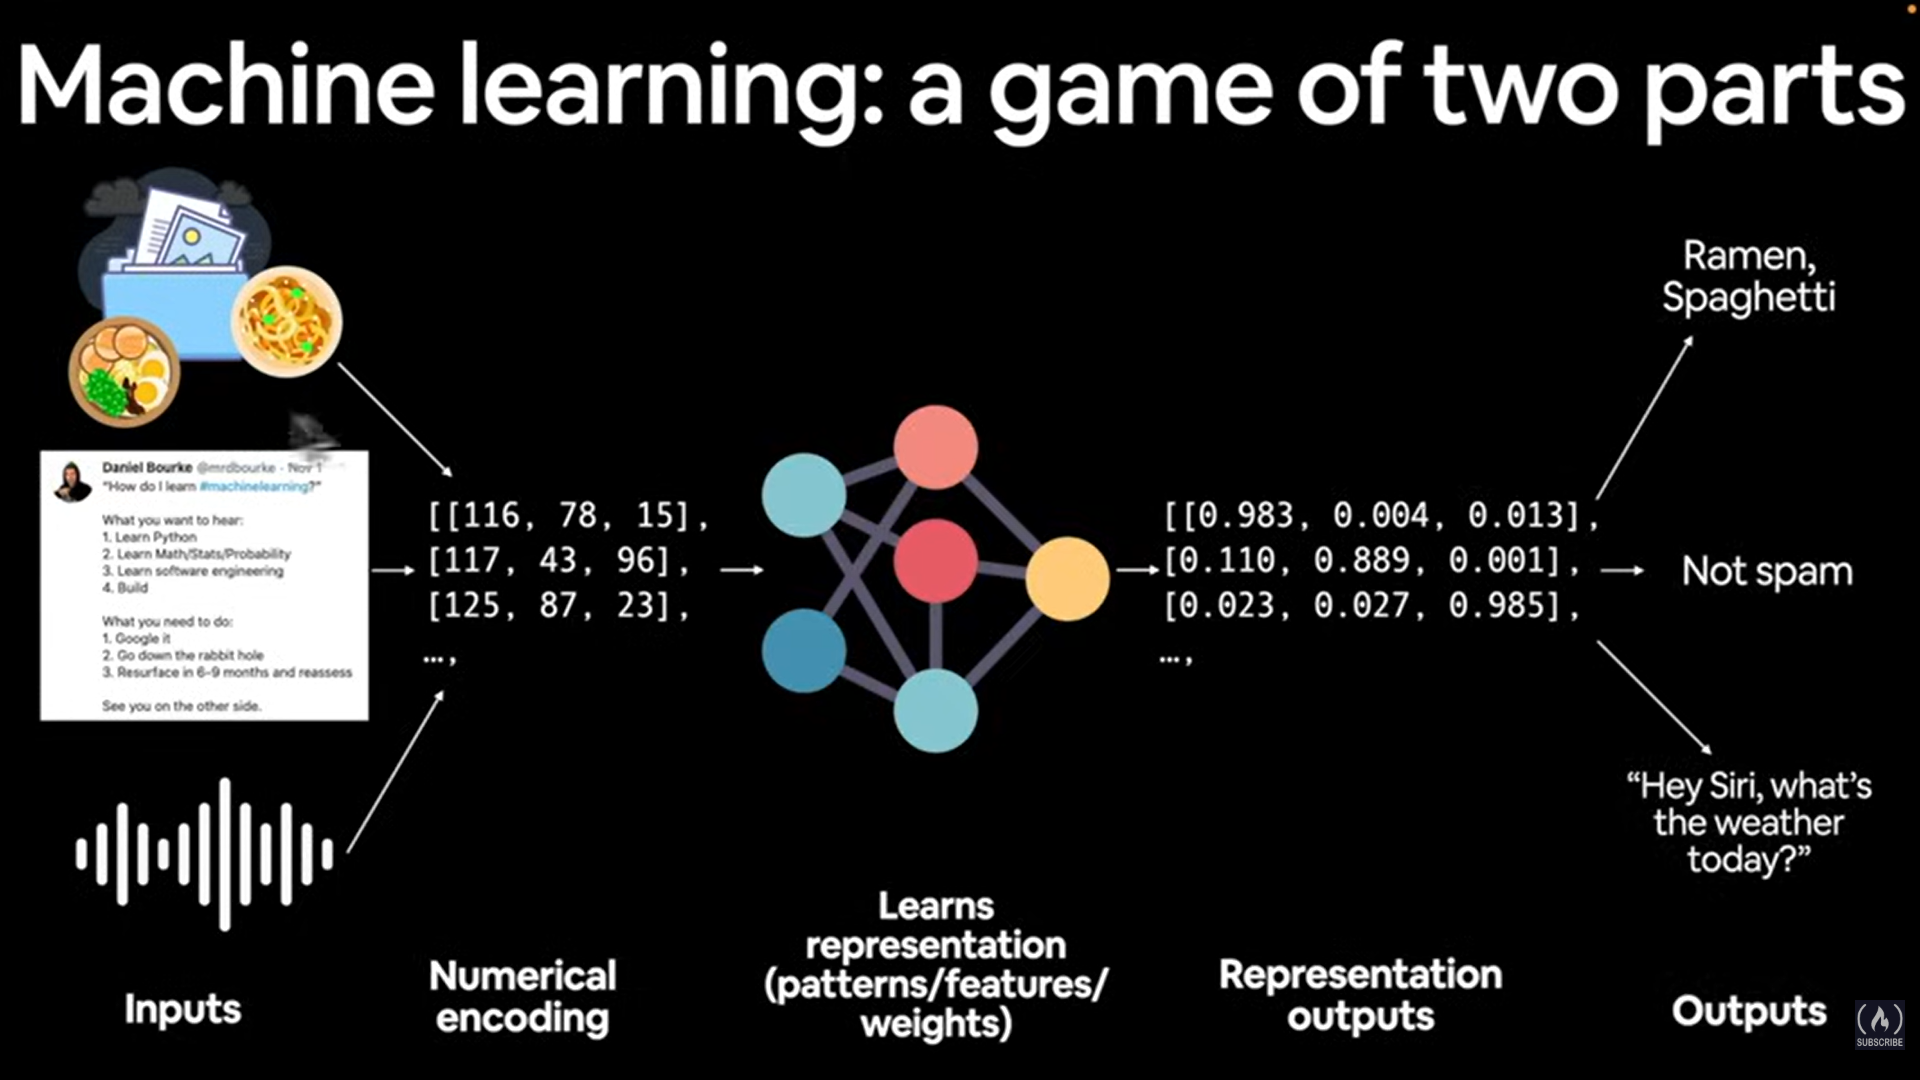

to know let's use linear regression

make a straight line with known parameters

create known parameters

In [51]:
weight=0.7
bias=0.3

#create
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X +bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [52]:
len(X),len(y)

(50, 50)

In [53]:
### splitting data into training and test set
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)


(40, 40, 10, 10)

In [54]:
X_train,y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

better data visualisation

plot.scatter() is a Pandas plotting function used to create a scatter plot between two columns of a DataFrame

plt.legend() is used to display a legend on a plot. The legend helps identify which line, scatter points, or bars correspond to which dataset.

import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y1 = [2, 4, 6, 8]
y2 = [1, 3, 5, 7]

plt.plot(x, y1, label='Dataset 1')
plt.plot(x, y2, label='Dataset 2')

plt.legend()
plt.show()

In [55]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    ## plot the figure
    plt.figure(figsize=(10,7))
    ## training data in blue
    plt.scatter(train_data,train_labels,c="b",s=4,label="training data")
    ## testing data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="testing data")
    if predictions is not None:
        ## prediction data in red
        plt.scatter(test_data,predictions,c="r",s=4,label="predictions")
    ## show the legend
    plt.legend(prop={"size":14})
#

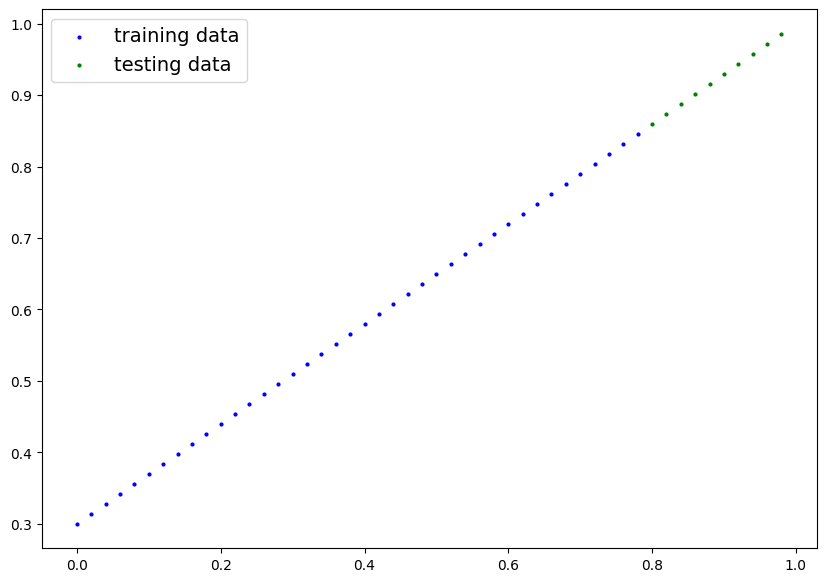

In [56]:
plot_predictions();

build model
our first PyTorch Model
linear regression model

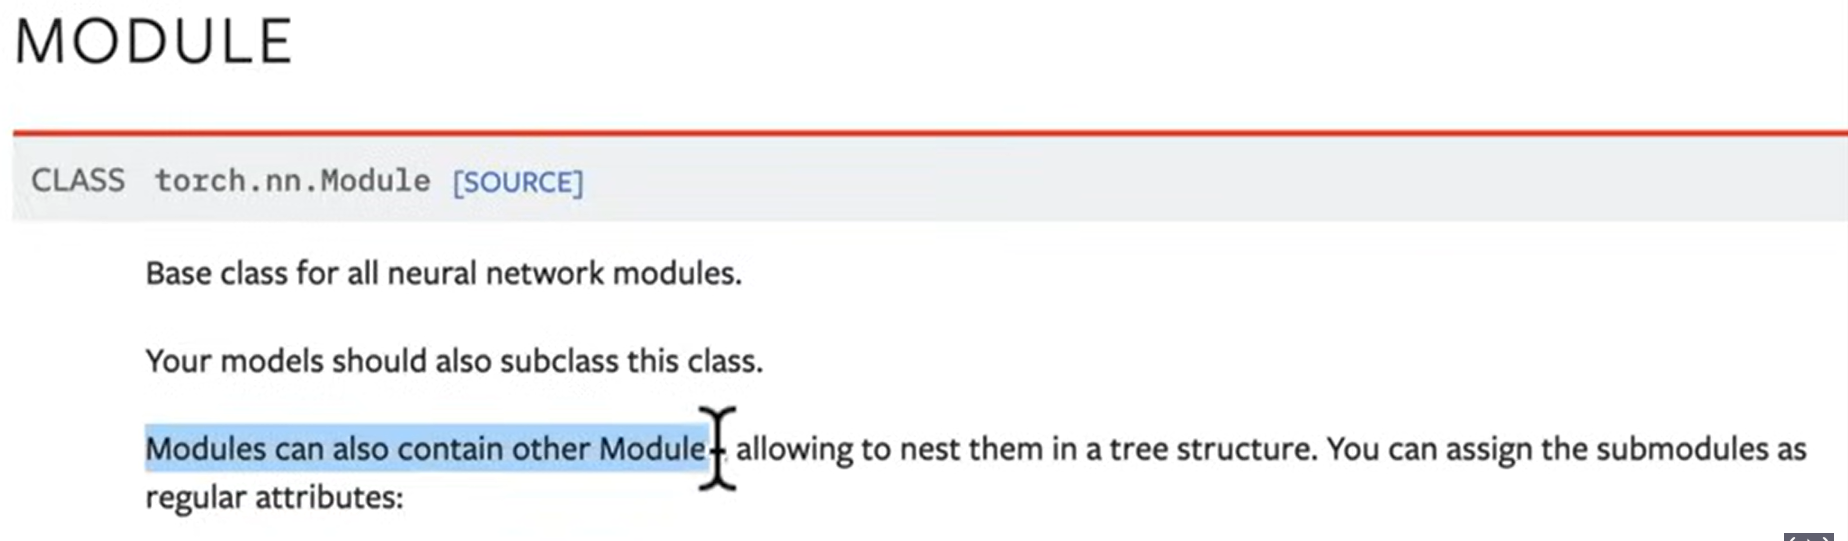



def __init__(self):

This method runs when you create an object of the class.
It is used to initialize the model's parameters and layers.

model = LinearRegressionModel()
When this line runs, __init__() is called automatically.

super().__init__()
Calls the constructor of nn.Module.
This sets up all the internal machinery PyTorch needs.

Without this line, PyTorch won't properly track your parameters.

Weight Parameter
self.weights = nn.Parameter(
    torch.rand(1, requires_grad=True, dtype=torch.float)
)

torch.rand(1)

Creates one random number between 0 and 1.

Example:

tensor([0.5342])
requires_grad=True

Tells PyTorch:

"Compute gradients for this value during backpropagation."

This allows the optimizer to learn the best weight.

nn.Parameter(...)

Registers the tensor as a trainable model parameter.

Without nn.Parameter, PyTorch wouldn't know it should update this value.

Bias Parameter
self.bias = nn.Parameter(
    torch.rand(1, requires_grad=True, dtype=torch.float)
)

Creates another trainable parameter.

In linear regression:

y=wx+b
w = weight
b = bias

Both are learned during training.

Forward Method
def forward(self, x):
    return self.weights * x + self.bias

This defines how data flows through the model.

Suppose:

weight = 2
bias = 1
x = 3

Then:

y = 2 * 3 + 1

Output:

7

This is exactly what the model computes.

Creating the Model
model = LinearRegressionModel()

Example output:

weight = 0.73
bias = 0.15

Initially these values are random.

Viewing Parameters
print(model.state_dict())

Output:

OrderedDict([
    ('weights', tensor([0.73])),
    ('bias', tensor([0.15]))
])

state_dict() shows all trainable parameters in the model.

Training Process

Initially:

weights = 0.73
bias = 0.15

Suppose the true equation is:

y = 0.7x + 0.3

PyTorch will:

Make predictions.
Compute loss.
Calculate gradients.
Update weight and bias.

After many epochs:

weights ≈ 0.7
bias ≈ 0.3

The model has "learned" the relationship.

Visual Summary
Input x
   │
   ▼
y = weight * x + bias
   │
   ▼
Prediction

Where:

weight = slope of line
bias   = intercept

So this entire model is simply teaching PyTorch to learn the equation:

y=wx+b

which is the mathematical form of a straight line.

what our model does:
*start with random values(weight and bias)

*look at training data and adjust random values to better represent(or get closer to) the ideal values (the weight and bias values we used to create the data)

2 main algorithms
1. gradient descent
2.backpropagation


In [57]:

from torch import nn
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
    self.bias=nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))

## forward method to define the computation in the model
  def forward(self,x): #<- "x is the input data"
    return self.weights*x+self.bias  #linear regression formula

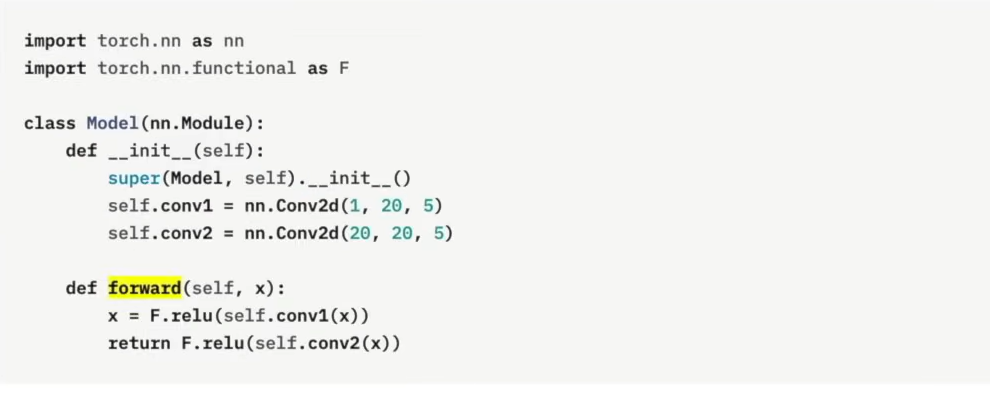

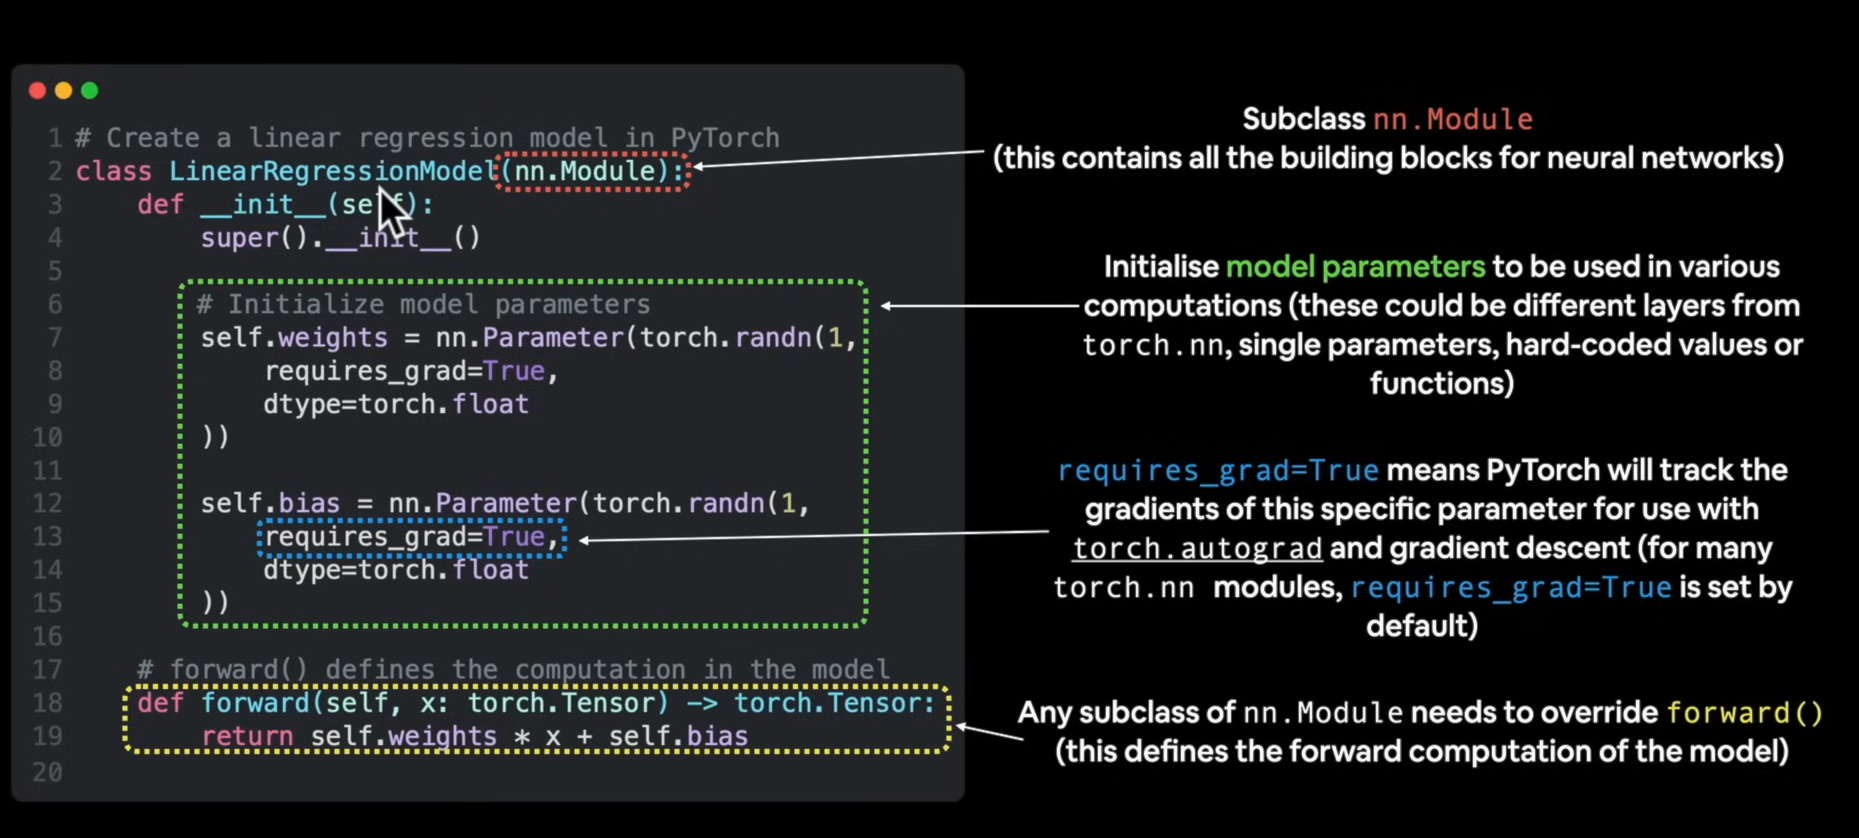

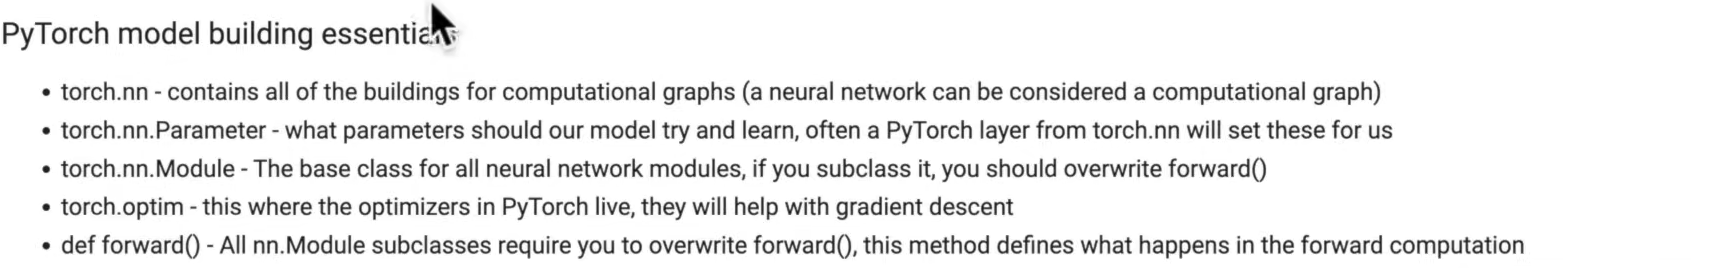

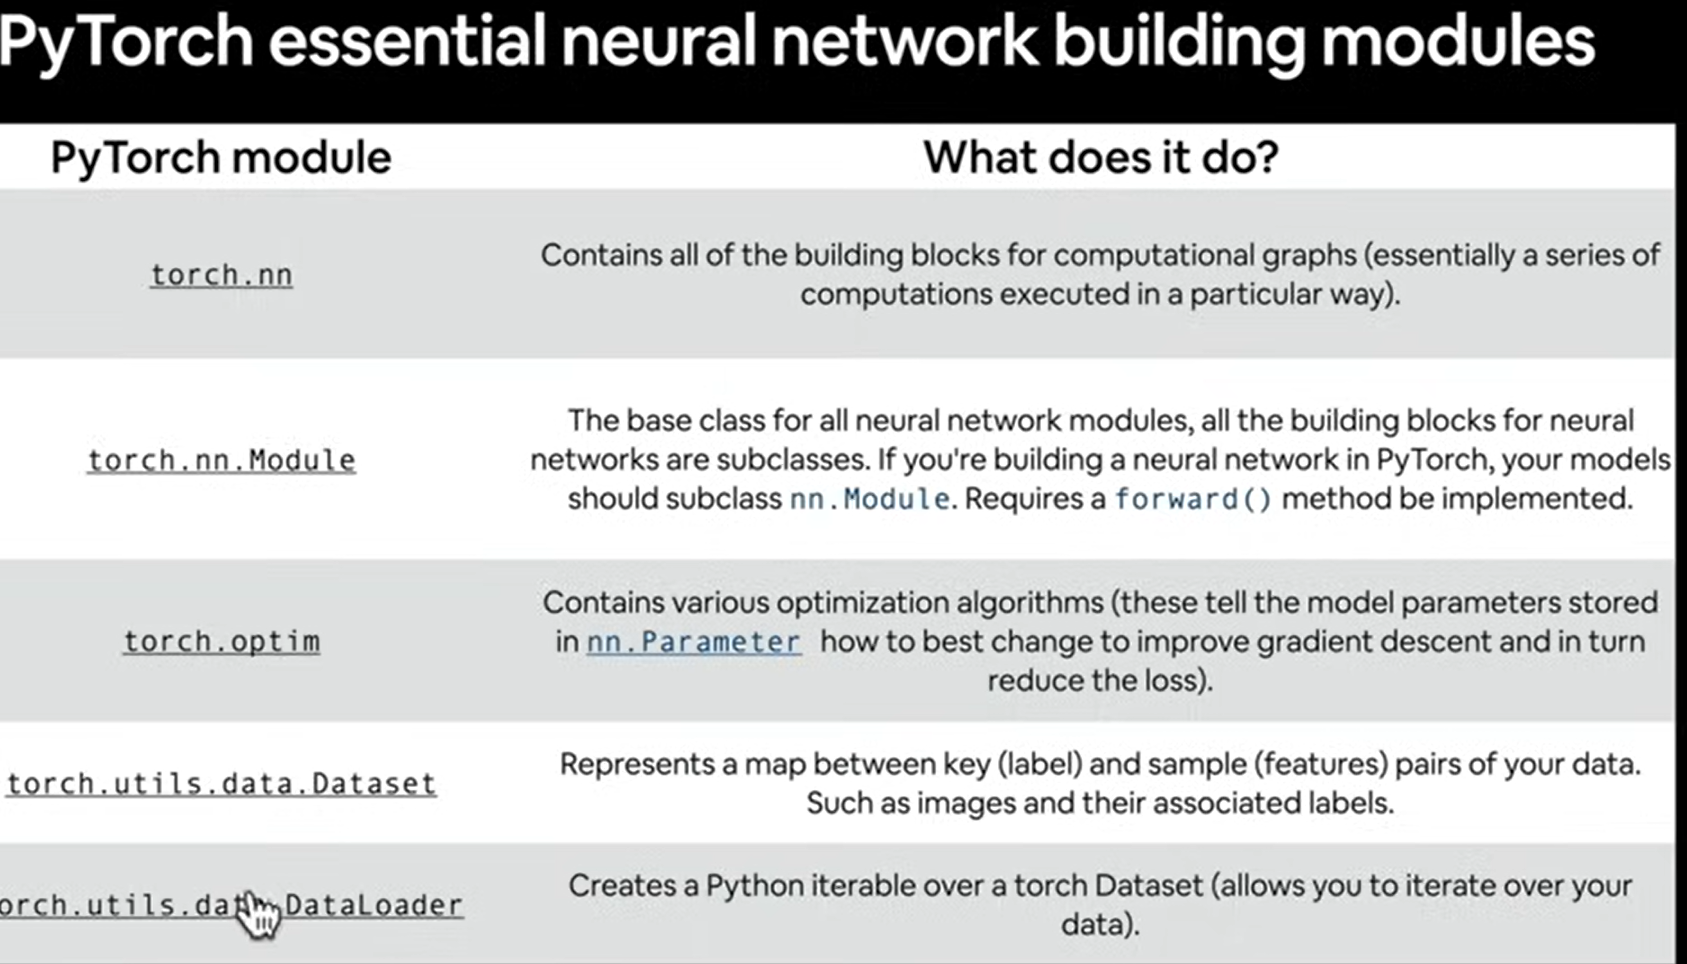

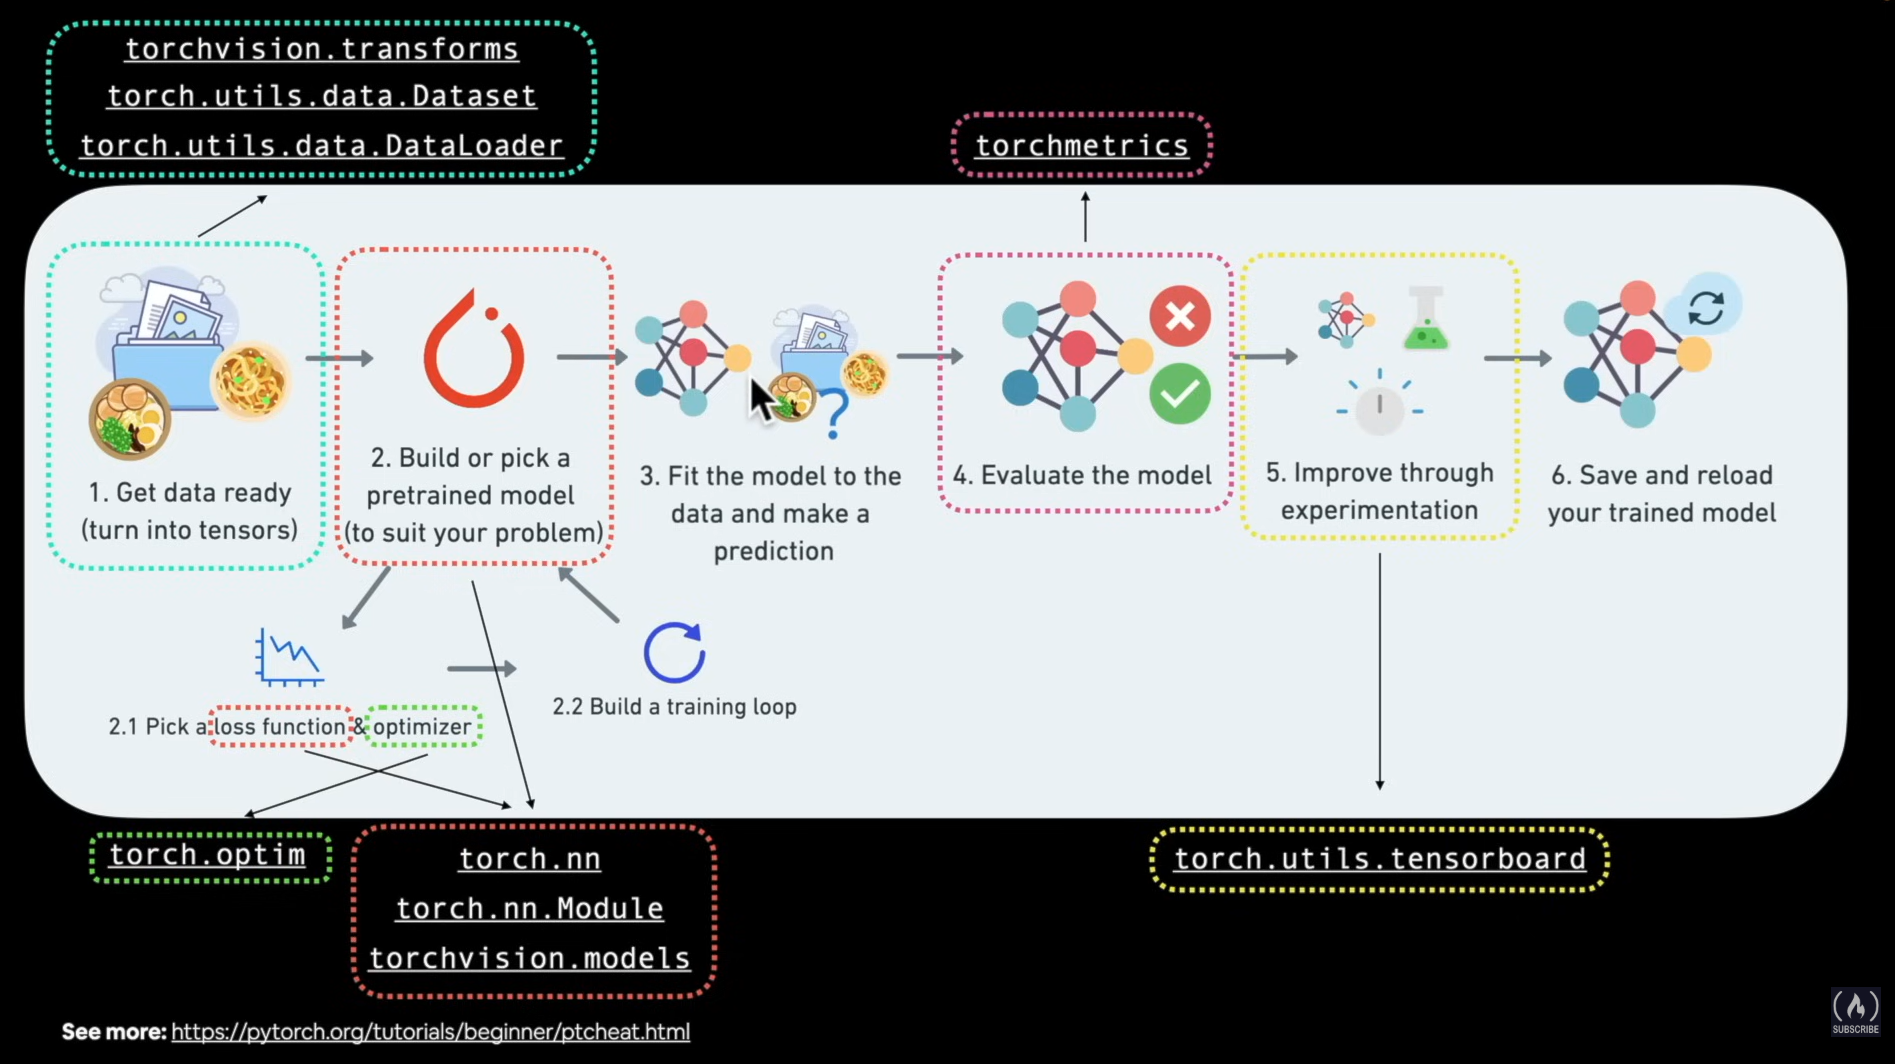

to get the same value everytime we use torch.randomseed

In [58]:
### checking contents of pytorch model using .parameters()
### create a random seed as model built on random data
torch.manual_seed(42)
### create an instance of the model (this is subclass of nn.Module)
model_0=LinearRegressionModel()
### check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [59]:
##list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [60]:
weight,bias

(0.7, 0.3)

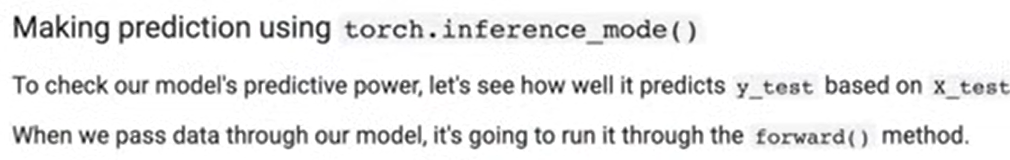

In [61]:
X_test,y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [62]:
y_preds=model_0(X_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

Inference mode turns off the gradient tracking torch.nograd() also does the same but inference mode preferred

In [63]:
## make prediction using 'torch.inference_model
with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [64]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

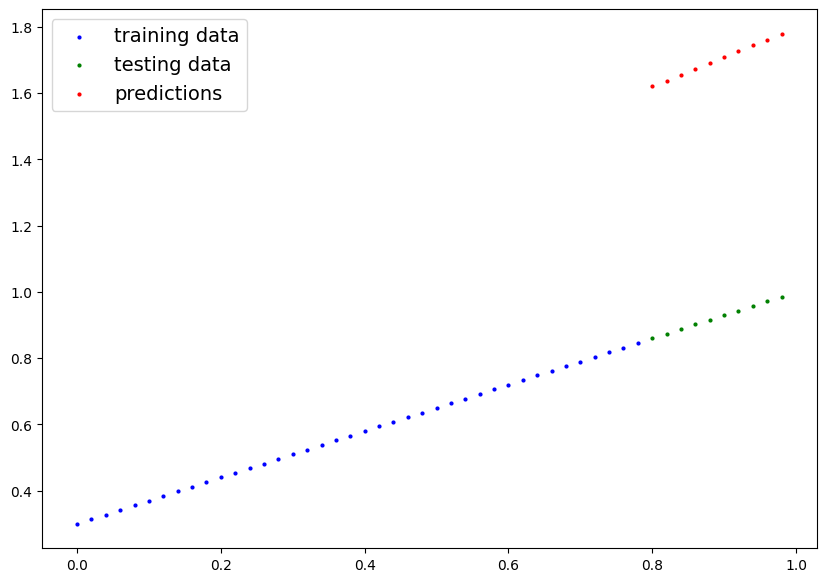

In [65]:
plot_predictions(predictions=y_preds)

 3. Train model
move from unknown parameters to known parameters
from poor representation of data to better representation
use loss function to understand how much error. also called criterion

loss function: how far from the model's predictions to the ideal value

one way measure distance

things we need to train::

Loss Function:: a function to measure how wrong your model's predictions are to the actual output

Optimizer:: takes into account the loss of a model and adjust the model's parameters to improve the loss function

and specifically for pytorch we need
1. A training loop
2. A testing loop

In [66]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [67]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

nn.L1loss for loss function
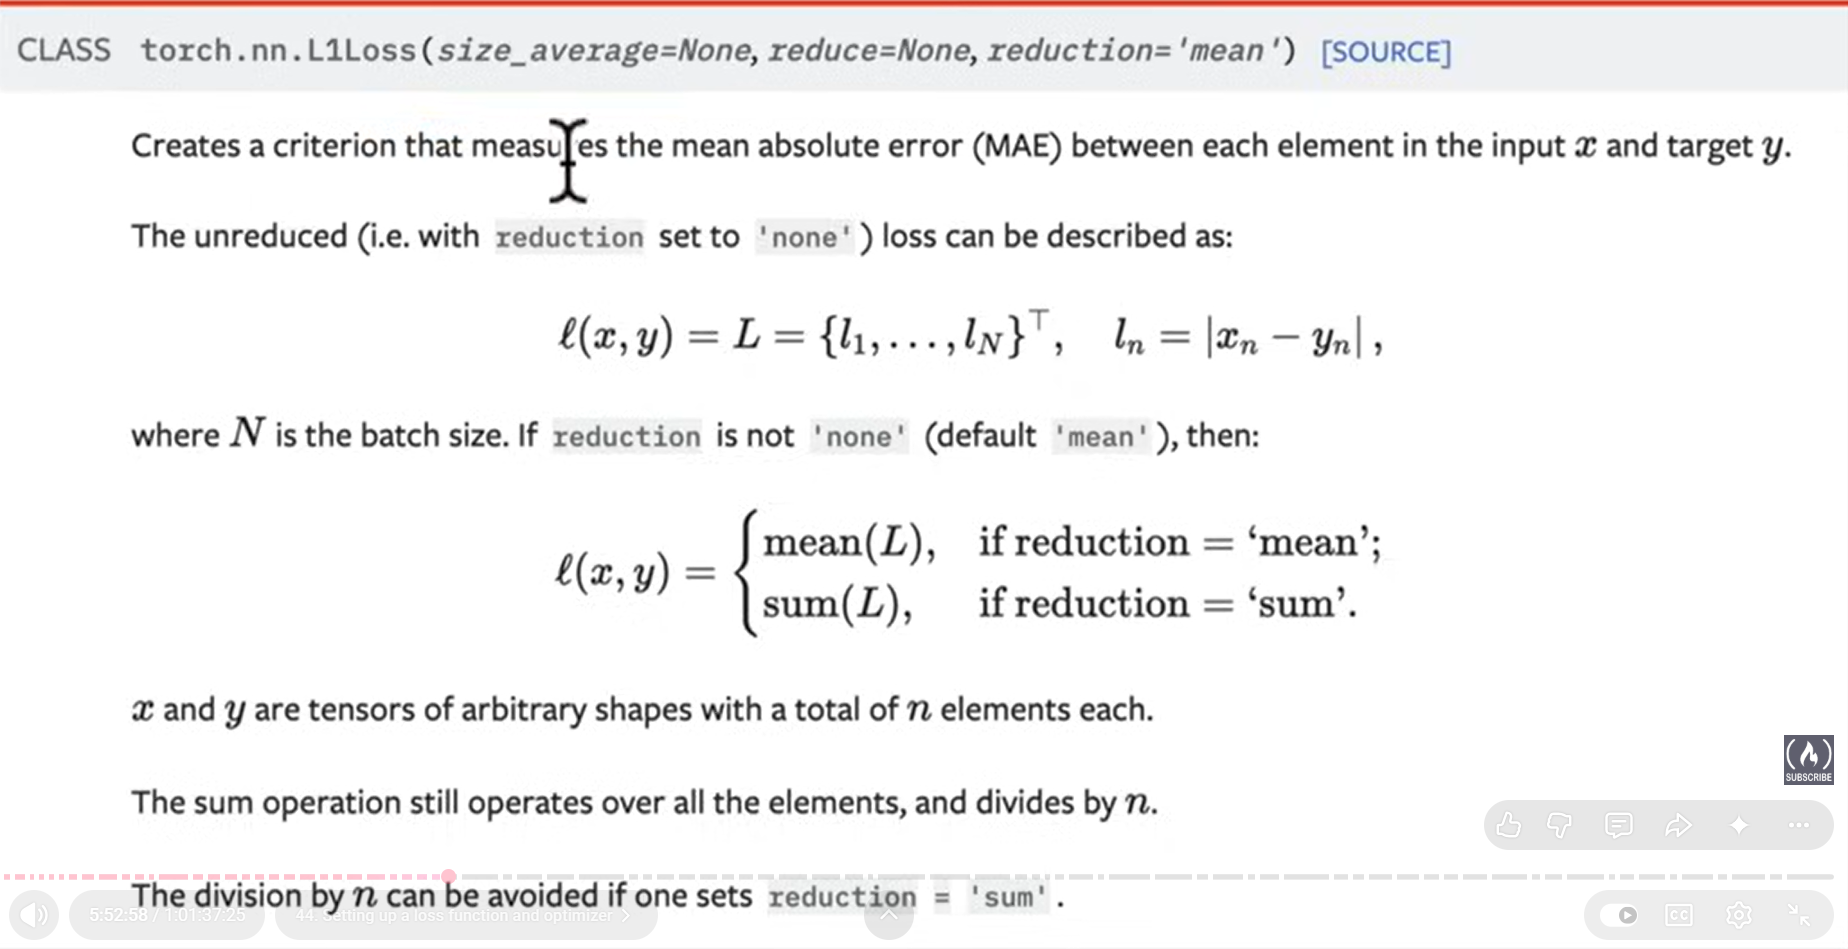

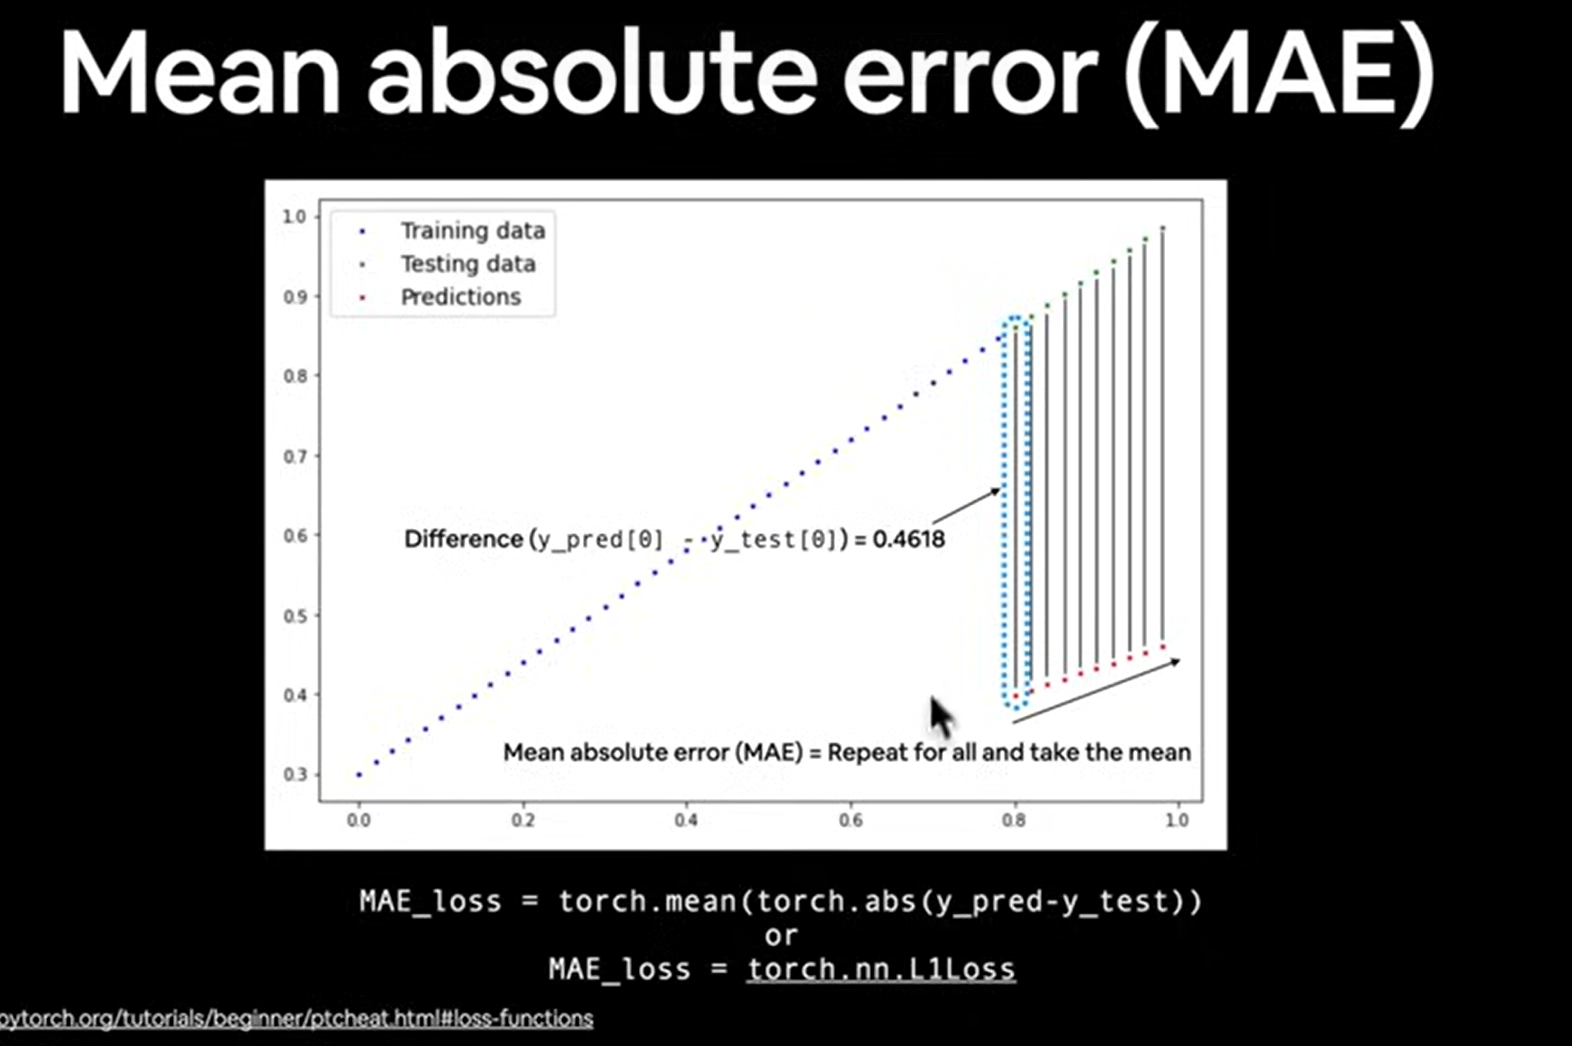

In [70]:
# Setup a loss function
loss_fn =nn.L1Loss()

#Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01) #learning rate= most imp hyperparameter

smaller learning rate smaller change in parameter larger learning rate in parameter

In [71]:
loss_fn


L1Loss()

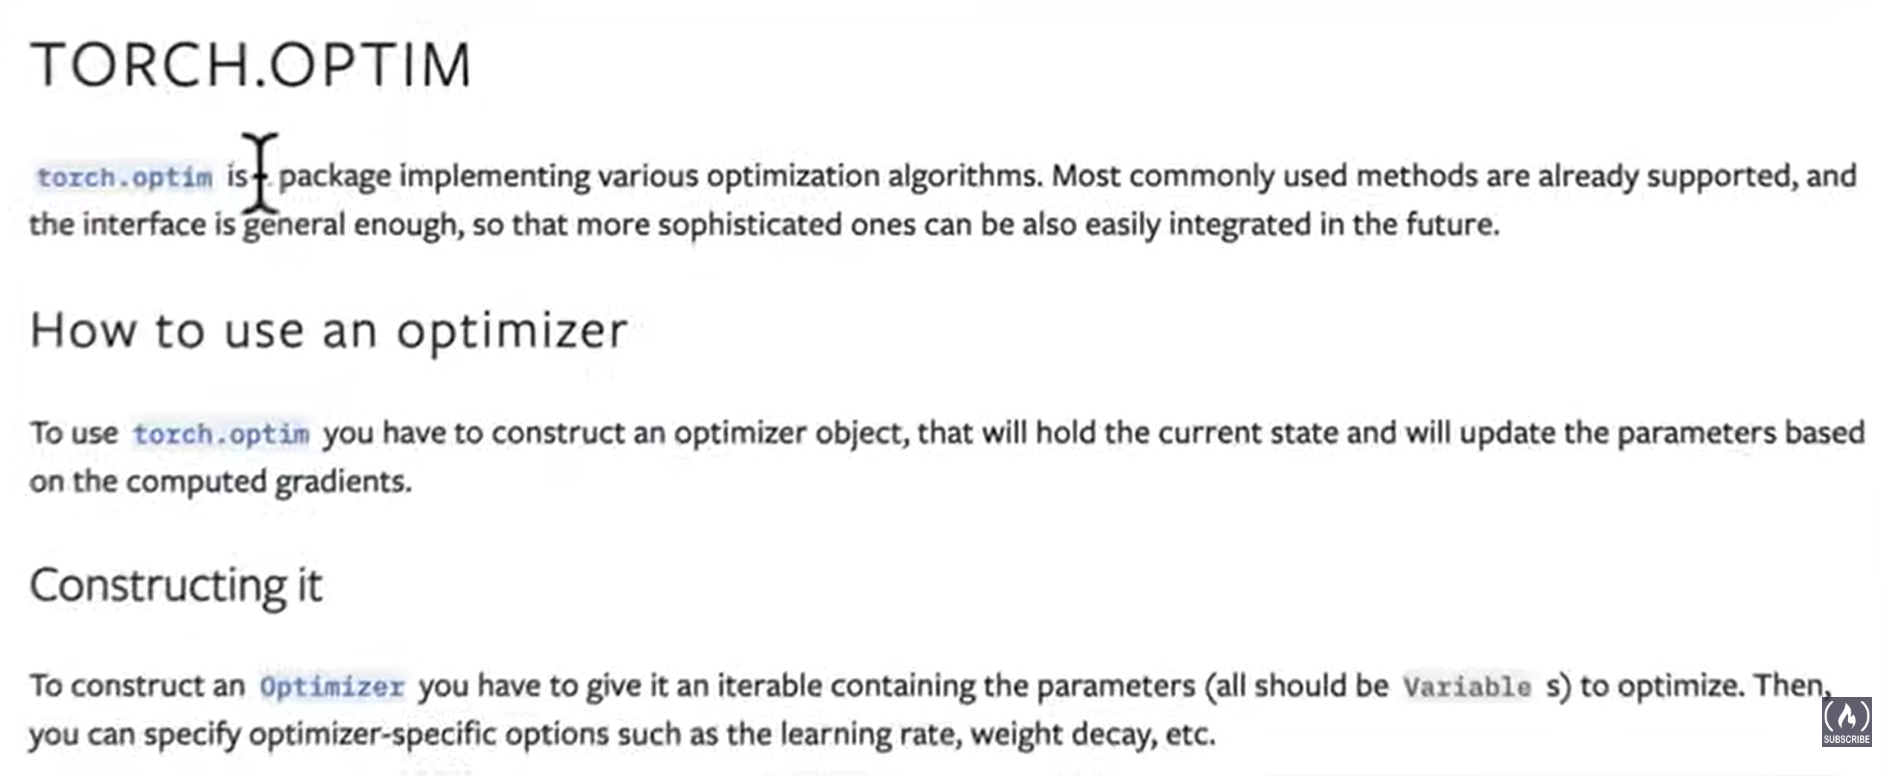

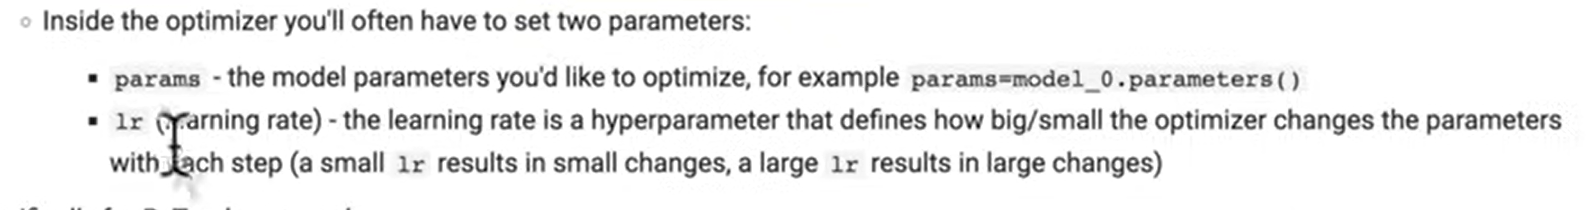

In [72]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

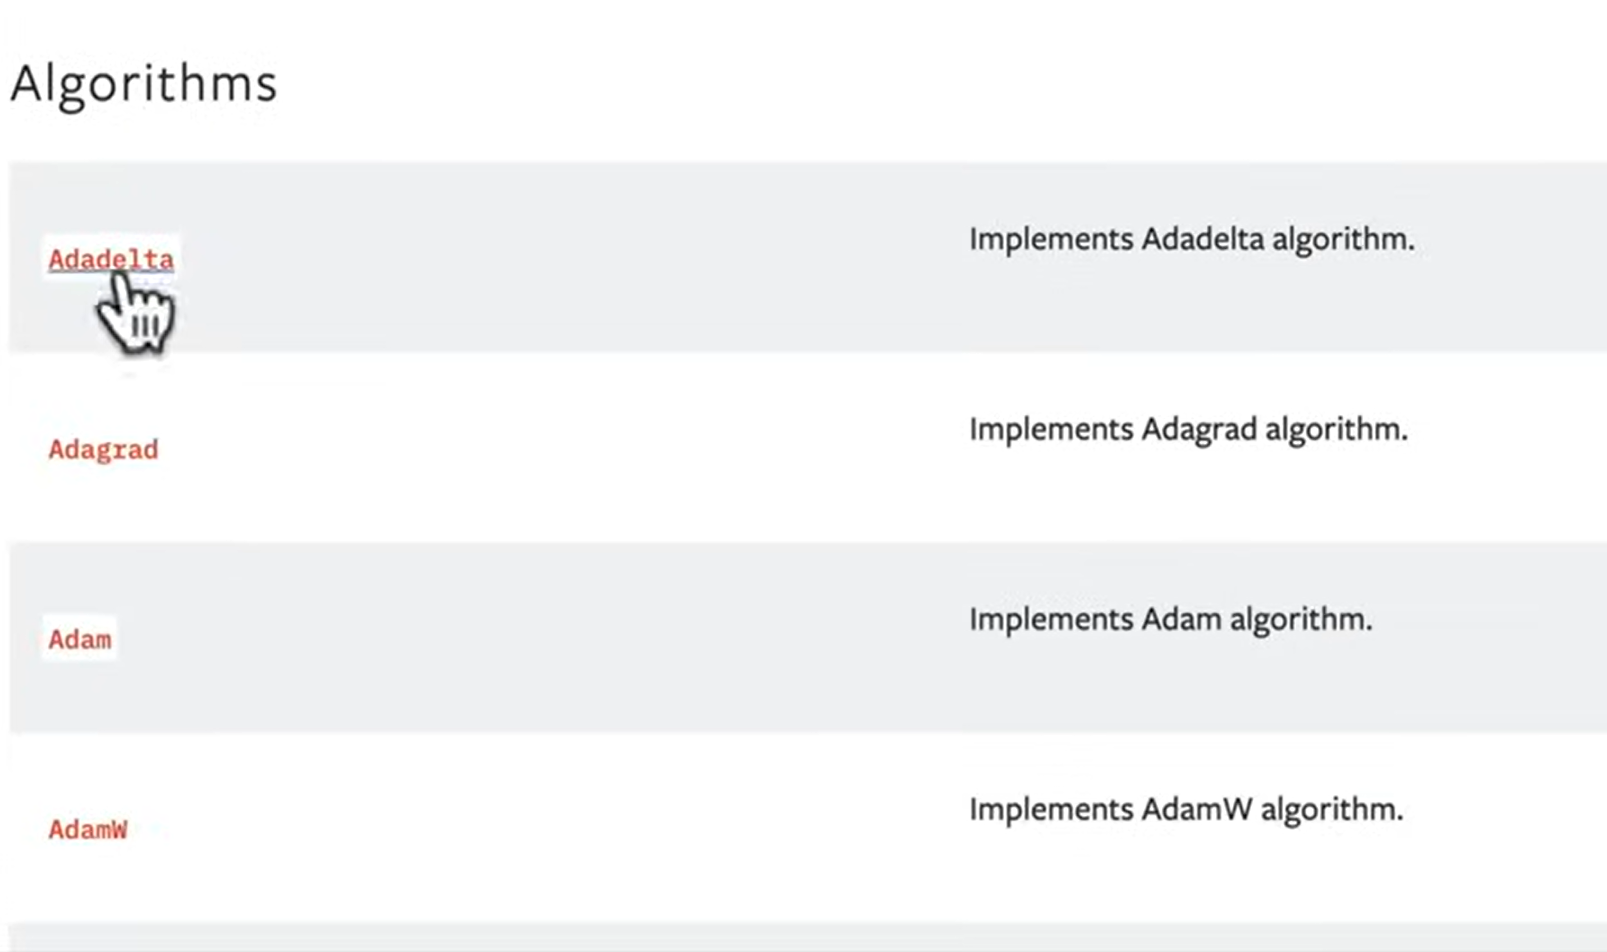

SGD is another popular optimizer improves gradient descent

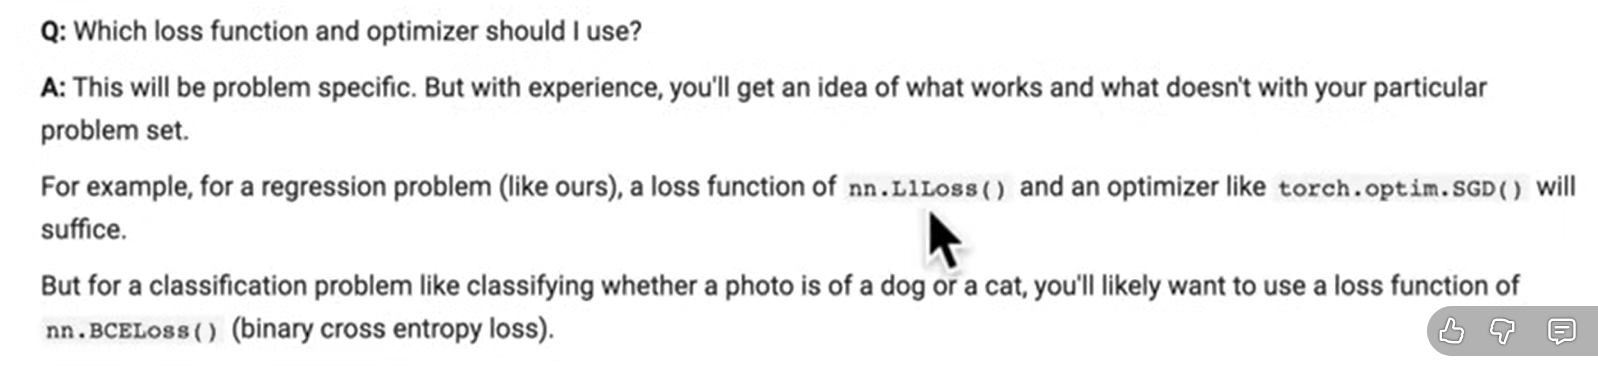